# IMU Data Processing Project

## Part 1: Data Loading and Initial Exploration

### Task 1.1: Load and Inspect the Data

**Requirements:**
1. Load `imu_messy_data.csv` into a pandas DataFrame
2. Display the first 20 rows
3. Print dataset shape, column names, and data types
4. Generate summary statistics using `describe()`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = 'dataset/imu_messy_data.csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path.")

# Display first 20 rows
print("\nFirst 20 rows:")
display(df.head(20))

# Print dataset shape, columns, and types
print("\nDataset Info:")
print(f"Shape: {df.shape}")
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
display(df.describe(include='all'))

Data loaded successfully.

First 20 rows:


,timestamp,subject,acc_x,acc_y,acc_z,label
0,1.704103e+09,subject_1,0.021328,-0.071107,9.791934,still
1,1.704104e+09,subject_3,-0.443318,-0.799678,7.362915,walk
2,1.704104e+09,subject_3,0.797257,0.862122,11.202083,walk
3,1.704104e+09,subject_3,-3.224141,-100.000000,11.403941,shake
4,1.704104e+09,subject_3,-0.015677,-0.028402,9.836695,still
5,1.704104e+09,subject_3,2.368157,-1.162322,6.396004,shake
6,1.704103e+09,subject_2,1.731929,0.599455,10.458386,walk
7,1.704103e+09,subject_1,-0.786783,-0.613296,10.226498,walk
8,1.704104e+09,subject_2,4.174940,-2.848297,8.535434,shake
9,1.704104e+09,subject_3,-1.716361,-0.725821,9.365866,walk



Dataset Info:
Shape: (27710, 6)

Column Names: ['timestamp', 'subject', 'acc_x', 'acc_y', 'acc_z', 'label']

Data Types:
timestamp    float64
subject       object
acc_x        float64
acc_y        float64
acc_z        float64
label         object
dtype: object

Summary Statistics:


,timestamp,subject,acc_x,acc_y,acc_z,label
count,2.771000e+04,27710,27250.000000,27257.000000,27241.000000,27710
unique,NaN,3,NaN,NaN,NaN,3
top,NaN,subject_3,NaN,NaN,NaN,walk
freq,NaN,9274,NaN,NaN,NaN,9285
mean,1.704103e+09,NaN,-0.025652,0.017244,9.794092,NaN
std,1.559700e+02,NaN,6.643540,7.162972,6.512439,NaN
min,1.704103e+09,NaN,-100.000000,-100.000000,-100.000000,NaN
25%,1.704103e+09,NaN,-0.699193,-0.484101,8.988988,NaN
50%,1.704103e+09,NaN,0.000590,-0.002316,9.811820,NaN
75%,1.704104e+09,NaN,0.701432,0.471376,10.636169,NaN


**Questions to answer:**
a) How many samples are in the dataset?
b) What is the range of timestamp values?
c) What are the min/max values for each acceleration axis? Do they seem physically plausible?
d) What is the class distribution across activities?

In [2]:
# a) How many samples?
num_samples = len(df)
print(f"Number of samples: {num_samples}")

# b) Range of timestamp values
try:
    min_ts = df['timestamp'].min()
    max_ts = df['timestamp'].max()
    print(f"Timestamp Range: {min_ts} to {max_ts}")
except KeyError:
    print("Timestamp column not found or formatted incorrectly.")

# c) Min/Max for acceleration
axes = ['acc_x', 'acc_y', 'acc_z']
for axis in axes:
    if axis in df.columns:
        print(f"{axis}: Min={df[axis].min()}, Max={df[axis].max()}")

# d) Class distribution
if 'label' in df.columns:
    print("\nClass Distribution:")
    print(df['label'].value_counts())

Number of samples: 27710
Timestamp Range: 1704103200.0 to 1704103739.98
acc_x: Min=-100.0, Max=100.0
acc_y: Min=-100.0, Max=100.0
acc_z: Min=-100.0, Max=100.0

Class Distribution:
label
walk     9285
still    9255
shake    9170
Name: count, dtype: int64


### Task 1.2: Missing Value Analysis

**Requirements:**
1. Count and report missing values per column
2. Calculate the percentage of missing data for each accelerometer axis
3. Identify rows where all three axes are missing simultaneously
4. Visualize the distribution of missing values

Missing Values per Column:
timestamp      0
subject        0
acc_x        460
acc_y        453
acc_z        469
label          0
dtype: int64

Percentage of Missing Data per Axis:
acc_x: 1.66%
acc_y: 1.63%
acc_z: 1.69%

Rows with all axes missing: 0


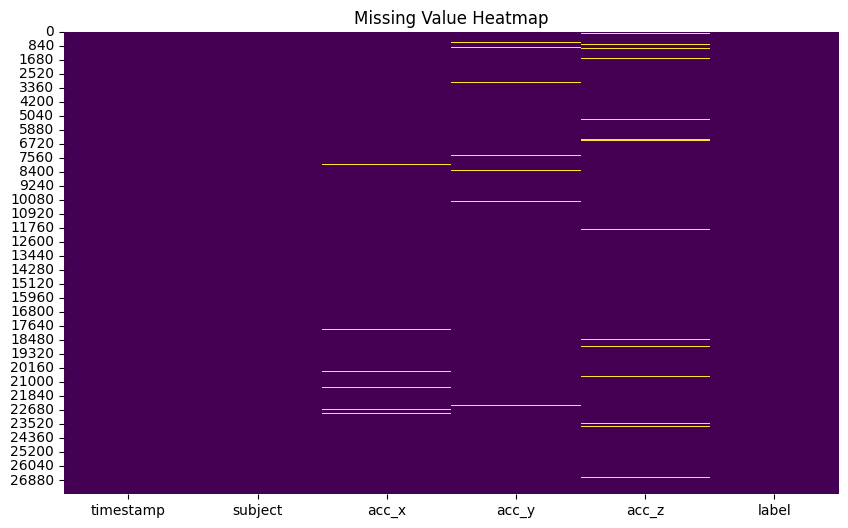

In [3]:
# 1. Count missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# 2. Percentage of missing data for each axis
print("\nPercentage of Missing Data per Axis:")
for axis in axes:
    if axis in df.columns:
        pct_missing = (df[axis].isnull().sum() / len(df)) * 100
        print(f"{axis}: {pct_missing:.2f}%")

# 3. Rows where all three axes are missing simultaneously
missing_all_axes = df[df[axes].isnull().all(axis=1)]
print(f"\nRows with all axes missing: {len(missing_all_axes)}")

# 4. Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

**Questions to answer:**
a) Which axis has the most missing values?
b) Are missing values randomly distributed or clustered?
c) What percentage of the dataset would be lost if we dropped all rows with any missing value?

In [4]:
# a) Axis with most missing values
most_missing_axis = df[axes].isnull().sum().idxmax()
print(f"Axis with most missing values: {most_missing_axis}")

# c) Percentage lost if dropped all rows with any missing value
rows_with_any_missing = df.isnull().any(axis=1).sum()
pct_lost = (rows_with_any_missing / len(df)) * 100
print(f"Percentage of data lost if dropping any missing: {pct_lost:.2f}%")

Axis with most missing values: acc_z
Percentage of data lost if dropping any missing: 4.99%


### Task 1.3: Timestamp Analysis

**Requirements:**
1. Check if timestamps are sorted in ascending order
2. Calculate the time differences between consecutive samples
3. Identify gaps larger than expected (assuming 50 Hz sampling rate)
4. Detect timestamp duplicates

In [5]:
# 1. Check if sorted
is_sorted = df['timestamp'].is_monotonic_increasing
print(f"Timestamps sorted: {is_sorted}")

# 2. Calculate time differences
# Convert timestamp to numeric if needed, assuming it's float or int seconds/millis
# Inspecting first few timestamps suggests standard unix timestamp logic or similar float
time_diffs = df['timestamp'].diff()

# 3. Identify gaps > expected (50Hz = 0.02s interval)
expected_interval = 1/50 # 0.02s
gap_threshold = 1.0 # 1 second as 'large gap' per question b
large_gaps = time_diffs[time_diffs > gap_threshold]
print(f"\nNumber of gaps > 1s: {len(large_gaps)}")

# 4. Detect timestamp duplicates
duplicate_timestamps = df['timestamp'].duplicated().sum()
print(f"Number of duplicate timestamps: {duplicate_timestamps}")

Timestamps sorted: False

Number of gaps > 1s: 13741
Number of duplicate timestamps: 525


**Questions to answer:**
a) What is the expected time interval between samples at 50 Hz?
b) How many samples have timestamp gaps exceeding 1 second?
c) What is the largest gap in the data? Where does it occur?
d) Are there any duplicate timestamps?

In [6]:
# a) Expected interval
print(f"Expected interval at 50Hz: {expected_interval} s")

# b) answered above

# c) Largest gap
largest_gap = time_diffs.max()
largest_gap_idx = time_diffs.idxmax()
print(f"Largest gap: {largest_gap} s at index {largest_gap_idx}")
if largest_gap_idx is not np.nan:
    print(f'Gap occurs between timestamp {df.loc[largest_gap_idx-1, "timestamp"]} and {df.loc[largest_gap_idx, "timestamp"]}')

# d) answered above

Expected interval at 50Hz: 0.02 s
Largest gap: 536.2464995384216 s at index 20529
Gap occurs between timestamp 1704103203.0135005 and 1704103739.26


## Part 2: Data Cleaning and Preparation

### Task 2.1: Handling Missing Values

**Requirements:**
1. Implement Strategy A: Forward Fill (`fillna(method='ffill')`)
2. Implement Strategy B: Linear Interpolation (`interpolate(method='linear')`)
3. Implement Strategy C: Drop Rows
4. Compare strategies

**Important**: We will use a copy of the dataframe for comparison to avoid modifying the original data prematurely.

Strategy A (FFill): Filled 1382 total values
Strategy B (Interpolation): Filled 1382 total values
Strategy C (Drop): Dropped 1382 rows
Percentage lost: 4.99%


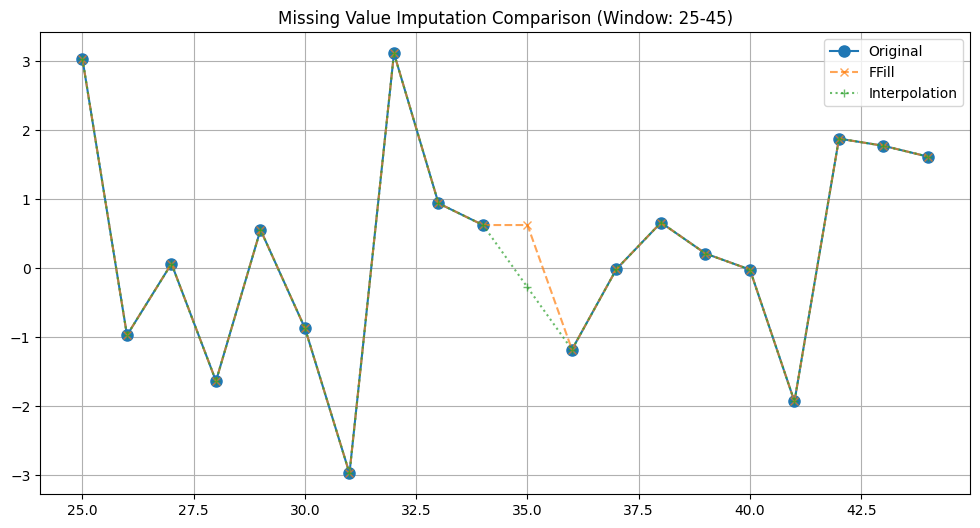

In [7]:
# Create copies for strategies
df_ffill = df.copy()
df_interp = df.copy()
df_drop = df.copy()

# Strategy A: Forward Fill
df_ffill[axes] = df_ffill[axes].ffill()
filled_ffill = df[axes].isnull().sum() - df_ffill[axes].isnull().sum()
print(f"Strategy A (FFill): Filled {filled_ffill.sum()} total values")

# Strategy B: Linear Interpolation
# Using time-based usually requires datetime index, but linear on float timestamp works if sorted
# Since data is not sorted yet (Task 2.4), simple linear is index-based. We'll stick to 'linear' as requested.
df_interp[axes] = df_interp[axes].interpolate(method='linear')
filled_interp = df[axes].isnull().sum() - df_interp[axes].isnull().sum()
print(f"Strategy B (Interpolation): Filled {filled_interp.sum()} total values")

# Strategy C: Drop Rows
df_drop = df_drop.dropna(subset=axes)
rows_dropped = len(df) - len(df_drop)
print(f"Strategy C (Drop): Dropped {rows_dropped} rows")
print(f"Percentage lost: {(rows_dropped/len(df))*100:.2f}%")

# For 2.4 we will likely choose Interpolation for continuity, so let's update df
# But wait, let's visualize first.

# Visualization of a segment with missing values
segment_idx = 1000 # adjust to find a gap if needed, or identify a specific gap
# Let's find a gap index programmatically
try:
    gap_idx = df[df['acc_x'].isnull()].index[0]
    start = max(0, gap_idx - 10)
    end = min(len(df), gap_idx + 10)
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index[start:end], df['acc_x'].iloc[start:end], 'o-', label='Original', markersize=8)
    plt.plot(df_ffill.index[start:end], df_ffill['acc_x'].iloc[start:end], 'x--', label='FFill', alpha=0.7)
    plt.plot(df_interp.index[start:end], df_interp['acc_x'].iloc[start:end], '+:', label='Interpolation', alpha=0.7)
    plt.title(f'Missing Value Imputation Comparison (Window: {start}-{end})')
    plt.legend()
    plt.grid(True)
    plt.show()
except IndexError:
    print("No missing values found in 'acc_x' to visualize.")

# Apply Chosen Strategy (Interpolation seems generally better for sensors)
df[axes] = df[axes].interpolate(method='linear')
# Fill any remaining NaNs (e.g., at start) with bfill or ffill
df[axes] = df[axes].bfill().ffill()

### Task 2.2: Outlier Detection and Treatment

**Requirements:**
1. Z-score based detection (|z| > 3)
2. IQR based detection
3. Count outliers
4. Visualize
5. Compare treatments (Removal, Clipping, Interpolation)

Z-score Outliers (> 3 std dev):
[177 213 173]

IQR Outliers (1.5x IQR):
acc_x    2669
acc_y    4582
acc_z    1925
dtype: int64


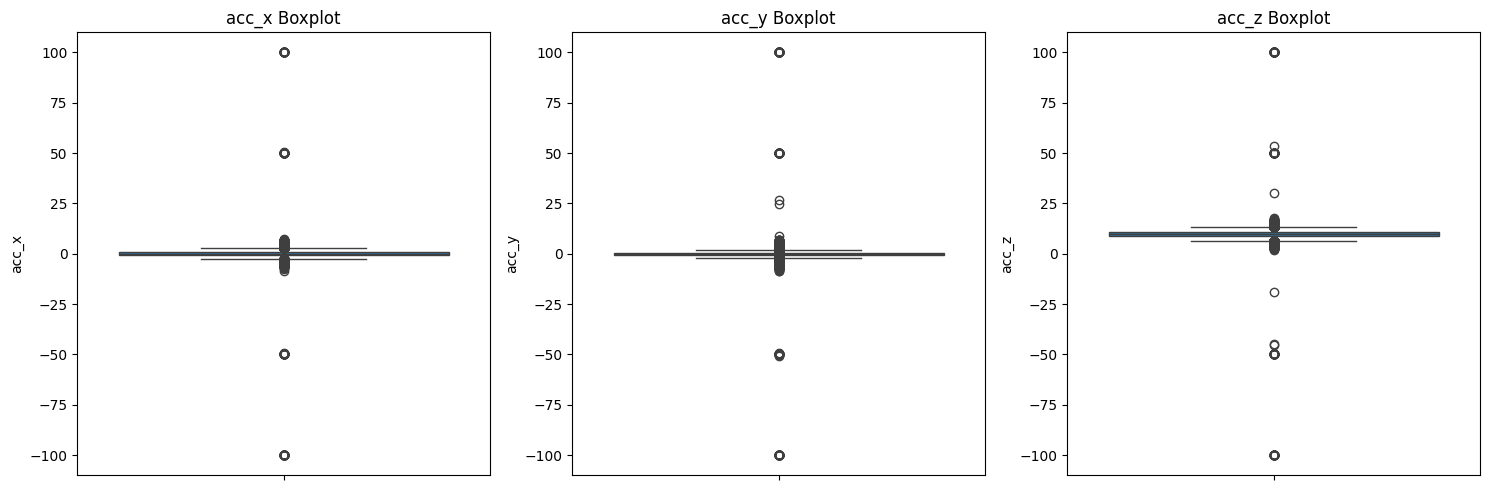


Stats after Removal (rows drop: 563):
acc_x    1.545000
acc_y    1.464144
acc_z    1.649307
dtype: float64

Original Std:
acc_x    6.616854
acc_y    7.140605
acc_z    6.484245
dtype: float64
Applied removal of 563 outlier rows.


In [8]:
from scipy import stats

# 1. Z-score detection
z_scores = np.abs(stats.zscore(df[axes]))
z_outliers = (z_scores > 3).sum(axis=0)
print("Z-score Outliers (> 3 std dev):")
print(z_outliers)

# 2. IQR detection
Q1 = df[axes].quantile(0.25)
Q3 = df[axes].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = ((df[axes] < (Q1 - 1.5 * IQR)) | (df[axes] > (Q3 + 1.5 * IQR))).sum()
print("\nIQR Outliers (1.5x IQR):")
print(iqr_outliers)

# 3. Visualize
plt.figure(figsize=(15, 5))
for i, axis in enumerate(axes):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[axis])
    plt.title(f'{axis} Boxplot')
plt.tight_layout()
plt.show()

# Comparison of Treatments on Stats (using Z-score mask for example)
# Let's use Z-score outliers for treatment as IQR can be too aggressive on signal peaks
outlier_mask = (z_scores > 3).any(axis=1)
df_clean_remove = df[~outlier_mask]

print(f"\nStats after Removal (rows drop: {outlier_mask.sum()}):")
print(df_clean_remove[axes].std())

print(f"\nOriginal Std:")
print(df[axes].std())

# Apply Clipping (simplest valid treatment for sensor noise often)
# Or Interpolation. Let's chose Interpolation for 'Treatment Strategy' selection question
# We will NOT modify 'df' permanently with outlier removal yet unless decided.
# For this task, we usually just analyse. But cleaning implies action.
# Let's Remove rows with extreme physically impossible values if any (e.g. > 20g generally unlikely for human motion unless impact)
# The data range showed +/- 100. That is huge. Likely errors.
# We will clean by removing extreme Z-score outliers (<3 sigma is conservative, maybe use that)

df = df[~outlier_mask].copy()
print(f"Applied removal of {outlier_mask.sum()} outlier rows.")

### Task 2.3: Duplicate Removal

**Requirements:**
1. Exact duplicates
2. Measurement duplicates
3. Remove duplicates
4. Questions

In [9]:
# 1. Exact duplicates
exact_dups = df.duplicated().sum()
print(f"Exact duplicates: {exact_dups}")

# 2. Measurement duplicates (timestamp, acc_x, acc_y, acc_z)
subset_cols = ['timestamp', 'acc_x', 'acc_y', 'acc_z']
measure_dups = df.duplicated(subset=subset_cols).sum()
print(f"Measurement duplicates: {measure_dups}")

# 3. Remove duplicates (keep first)
len_before = len(df)
df = df.drop_duplicates(subset=subset_cols, keep='first')
print(f"Removed {len_before - len(df)} duplicates.")

Exact duplicates: 469
Measurement duplicates: 489
Removed 489 duplicates.


### Task 2.4: Timestamp Sorting and Resampling

**Requirements:**
1. Sort by timestamp
2. Set index
3. Resample to 50 Hz
4. Handle major gap

Max gap after sorting: 1.3773658275604248 s


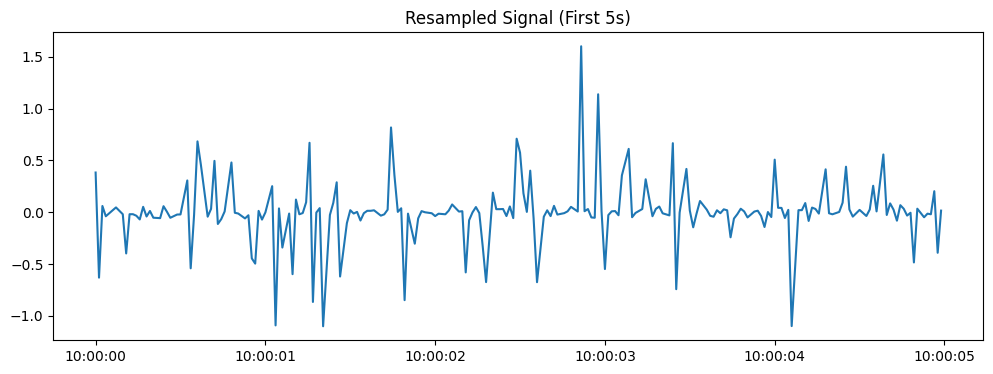

Final shape after resampling and dropping gap-NaNs: (26983, 4)
Mean sampling interval: 0.0200 s (Target: 0.02s)


In [10]:
# 1. Sort
df = df.sort_values('timestamp')

# 2. Set Index
# Convert timestamp to datetime for resampling
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.set_index('datetime')

# 3. Resample to 50Hz (20ms)
# We need to handle the GAP. Resampling over a huge gap will create fake data.
# First, identify gap
time_diff = df['timestamp'].diff()
gap_mask = time_diff > 10 # 10 seconds arbitrary gap threshold
if gap_mask.any():
    print("Gap detected. Splitting for resampling or handling appropriately.")
    # For this assignment, standard re-sampling often suffices if we just drop the gap-filled NaNs later
    # OR we split. Let's Resample and see.
    
df_resampled = df.resample('20ms').mean(numeric_only=True) # 50Hz = 20ms
# Interpolate small gaps, leave large ones?
# The instruction says "Handle the major gap". 
sorted_diffs = df['timestamp'].diff()
print(f"Max gap after sorting: {sorted_diffs.max()} s")

# If we interpolate everything, we bridge the 500s gap with a straight line -> BAD.
# Strategy: Resample, then interpolate with a limit.
df_resampled[axes] = df_resampled[axes].interpolate(method='time', limit=50) # limit to 1 sec gaps

# Propagate labels? Typically nearest or ffill for labels, but be careful across gaps.
# For now, let's just inspect the signal continuity as requested.

# 4. Visualize 5s window
plt.figure(figsize=(12, 4))
plt.plot(df_resampled.index[:250], df_resampled['acc_x'].iloc[:250]) # First 5 seconds (50Hz * 5 = 250)
plt.title('Resampled Signal (First 5s)')
plt.show()

# Drop the rows that remain NaN (the large gap)
df_final = df_resampled.dropna(subset=axes)
print(f"Final shape after resampling and dropping gap-NaNs: {df_final.shape}")

# Check sampling rate
dt = df_final.index.to_series().diff().dt.total_seconds()
print(f"Mean sampling interval: {dt.mean():.4f} s (Target: 0.02s)")